
First 5 rows:
    satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low 

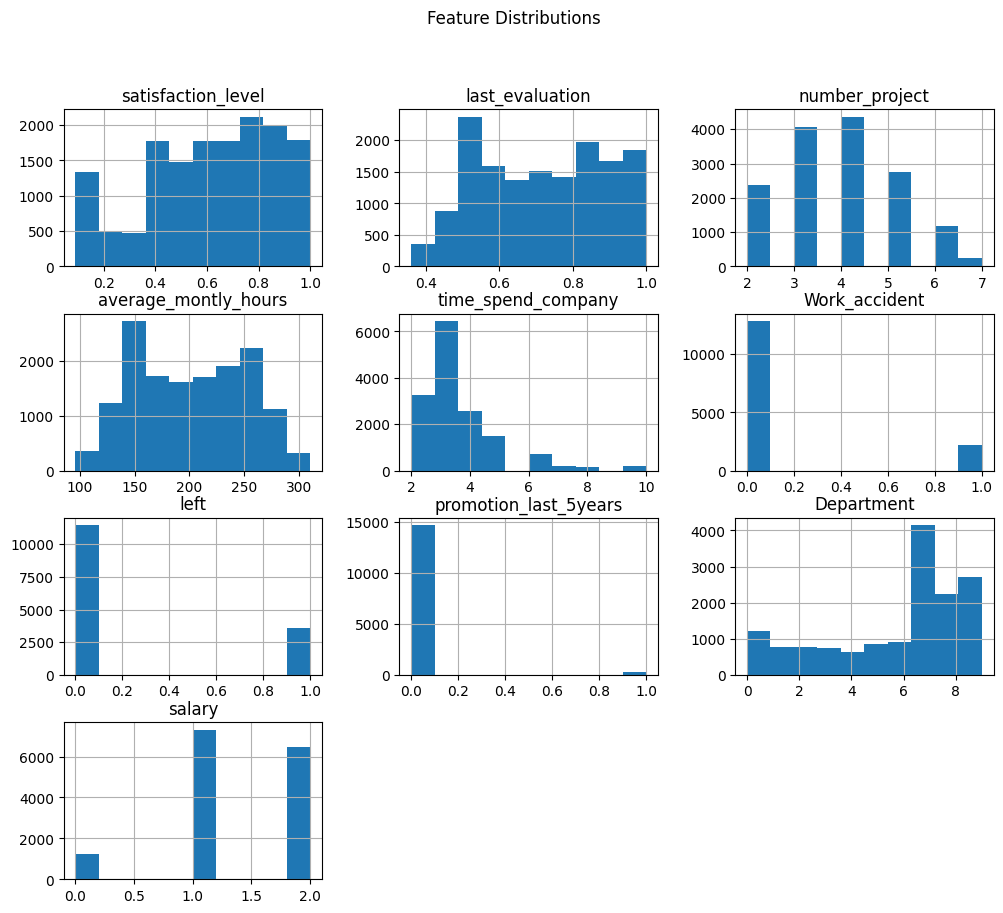

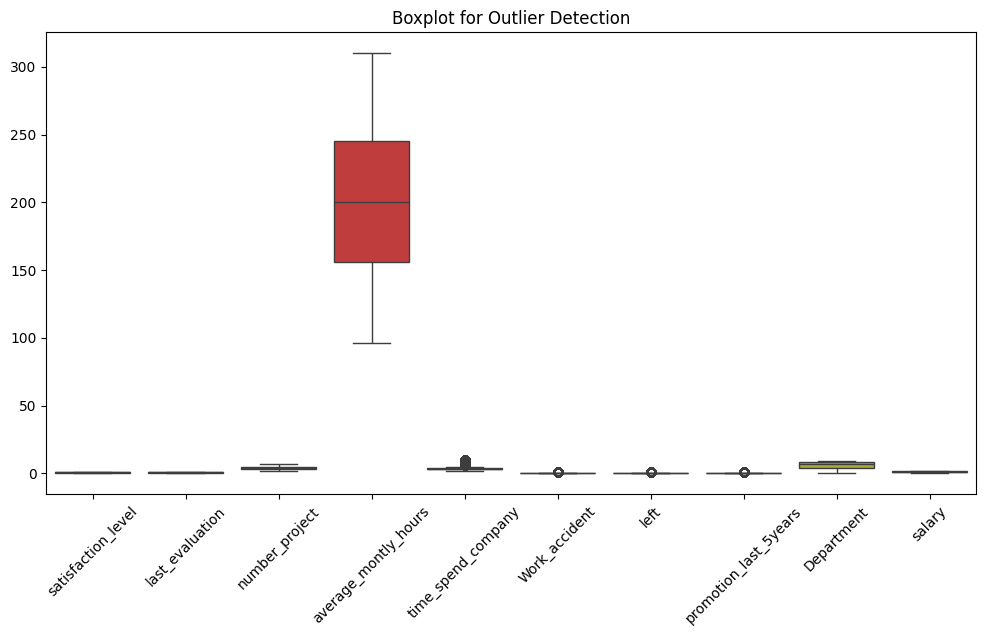


Shapiro-Wilk Normality Test:
satisfaction_level: p-value = 3.1637031058242057e-56
last_evaluation: p-value = 4.173381497944065e-56
number_project: p-value = 1.1401408166109706e-65
average_montly_hours: p-value = 2.7847822341816014e-51
time_spend_company: p-value = 1.0248726896775883e-86
Work_accident: p-value = 2.2205496323707956e-112
left: p-value = 6.470053309848732e-107
promotion_last_5years: p-value = 1.8335947414341428e-123
Department: p-value = 8.106463728669809e-79
salary: p-value = 2.244707827299723e-90


c:\Users\kjain\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14999.
  res = hypotest_fun_out(*samples, **kwds)


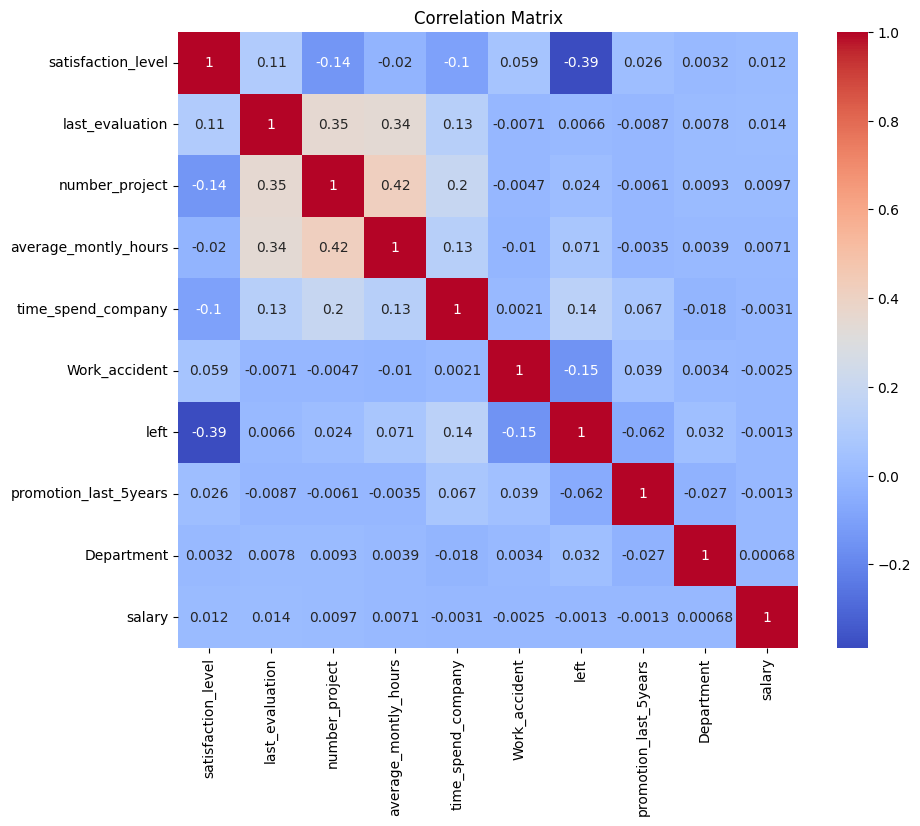


Accuracy: 0.989

Confusion Matrix:
 [[2287    7]
 [  26  680]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2294
           1       0.99      0.96      0.98       706

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



In [2]:
# ==============================
# STEP 1: IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==============================
# STEP 2: LOAD DATASET
# ==============================
df = pd.read_csv(r"C:\Users\kjain\Projects\MajorProject\HR_comma_sep.csv")

print("\nFirst 5 rows:\n", df.head())

# ==============================
# STEP 3: PREPROCESSING
# ==============================

# Encode categorical variables
le = LabelEncoder()
df['salary'] = le.fit_transform(df['salary'])
df['Department'] = le.fit_transform(df['Department'])

# Check missing values
print("\nMissing values:\n", df.isnull().sum())

# ==============================
# STEP 4: EDA
# ==============================

print("\nSummary Statistics:\n", df.describe())

# Histograms
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

# Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()

# ==============================
# STEP 5: NORMALITY TEST
# ==============================

print("\nShapiro-Wilk Normality Test:")
for col in df.select_dtypes(include=[np.number]).columns:
    stat, p = shapiro(df[col])
    print(f"{col}: p-value = {p}")

# ==============================
# STEP 6: CORRELATION ANALYSIS
# ==============================

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ==============================
# STEP 7: MACHINE LEARNING
# ==============================

# Target = left (attrition)
X = df.drop("left", axis=1)
y = df["left"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# ==============================
# STEP 8: EVALUATION
# ==============================

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [4]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==============================
# CREATE RESULTS FOLDER
# ==============================
if not os.path.exists("results"):
    os.makedirs("results")

# ==============================
# LOAD DATASET
# ==============================
df = pd.read_csv(r"C:\Users\kjain\Projects\MajorProject\HR_comma_sep.csv")

# ==============================
# PREPROCESSING
# ==============================
le = LabelEncoder()
df['salary'] = le.fit_transform(df['salary'])
df['Department'] = le.fit_transform(df['Department'])

# ==============================
# EDA
# ==============================

# Summary stats
summary = df.describe()
summary.to_csv("results/summary_statistics.csv")

# Histograms
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.savefig("results/histograms.png")
plt.close()

# Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot")
plt.savefig("results/boxplot.png")
plt.close()

# ==============================
# NORMALITY TEST
# ==============================
normality_results = []

for col in df.select_dtypes(include=[np.number]).columns:
    stat, p = shapiro(df[col])
    normality_results.append([col, p])

normality_df = pd.DataFrame(normality_results, columns=["Feature", "p-value"])
normality_df.to_csv("results/normality_test.csv", index=False)

# ==============================
# CORRELATION
# ==============================
corr = df.corr()
corr.to_csv("results/correlation_matrix.csv")

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig("results/correlation_heatmap.png")
plt.close()

# ==============================
# MACHINE LEARNING
# ==============================
X = df.drop("left", axis=1)
y = df["left"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ==============================
# EVALUATION
# ==============================
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Save results
with open("results/model_results.txt", "w") as f:
    f.write(f"Accuracy: {accuracy}\n\n")
    f.write("Confusion Matrix:\n")
    f.write(str(cm))
    f.write("\n\nClassification Report:\n")
    f.write(report)

print("All results saved in 'results/' folder")

c:\Users\kjain\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14999.
  res = hypotest_fun_out(*samples, **kwds)


All results saved in 'results/' folder


In [5]:
plt.figure(figsize=(12,10))  # Increase size

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size":8}  # smaller numbers
)

# Rotate labels properly
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title("Correlation Matrix Heatmap", fontsize=14)

plt.tight_layout()  # 🔥 THIS FIXES CUTTING

plt.savefig("results/correlation_heatmap.png", dpi=300)
plt.close()